In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle





In [4]:
import pandas as pd
from rdkit.Chem import PandasTools

file = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Skin Sensitization\dataset\train_set_skin_sensitization_features_rdkitcdk.sdf"
sdfInfo = dict(smilesName='SMILES', molColName='ROMol')
moldf = PandasTools.LoadSDF(file, **sdfInfo)
moldf = moldf.rename(columns={'ROMol': 'Mol'})
moldf = moldf.drop_duplicates(subset=['SMILES'])
moldf = moldf[pd.notnull(moldf['Mol'])]
print(moldf.shape)
print(moldf.columns)


[15:13:09] WARNING: not removing hydrogen atom without neighbors
[15:13:09] WARNING: not removing hydrogen atom without neighbors
[15:13:09] WARNING: not removing hydrogen atom without neighbors


(794, 68)
Index(['Compound name', 'Outcome', 'LLNA class', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'ID', 'SMILES',
       'Molecular Weight', 'logP', 'LabuteASA', 'TPSA', 'AMW',
       'NumLipinskiHBA', 'NumLipinskiHBD', 'NumRotatableBonds', 'NumHBD',
       'NumHBA', 'NumAmideBonds', 'NumHeteroAtoms', 'NumAtoms', 'NumRings',
       'NumAromaticRings', 'NumSaturatedRings', 'NumAliphaticRings',
       'NumAromaticHeterocycles', 'NumSaturatedHeterocycles',
       'NumAliphaticHeterocycles', 'NumAromaticCarbocycles',
       'NumSaturatedCarbocycles', 'NumAliphaticCarbocycles', 'FractionCSP3',
       'Chi0v', 'Chi1v', 'Chi2v', 'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n',
       'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2', 'kappa3', 'ALogP',
       'ALogP2', 'AMR', 'MLogP', 'nAtomP', 'naAromAtom', 'bpol', 'nB', 'ECCEN',
       'fragC', 'nHBAcc', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber',
       'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMa

In [5]:
moldf

,Compound name,Outcome,LLNA class,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
0,2-Methyl-5-nitrobenzenesulfonic acid,1,,278,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2618503396950841, -0.2395050914825213, 0.29...",278,Cc1ccc([N+](=O)[O-])cc1S(=O)(=O)O,217.004493324,...,0.0,3.0,0.5,2.0,0.0,105.89,4.807354922057604,0.7339999999999998,0.1428571428571428,<rdkit.Chem.rdchem.Mol object at 0x000001F2B84...
1,2-{4-chloro-3-[(4-ethoxyphenyl)methyl]phenyl}-...,1,,295,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.05548471118588, 1.0726857698606813, 1.08843...",295,CCOc1ccc(Cc2cc(C3(OC)OC(CO)C(O)C(O)C3O)ccc2Cl)cc1,438.14453088399995,...,2.0,3.0,0.4666666666666667,7.0,0.0,108.61,6.0,2.571,0.4545454545454545,<rdkit.Chem.rdchem.Mol object at 0x000001F2B84...
2,Eugenol,1,Weak,56,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.40585377622973534, -0.3327703846875663, -0...",56,C=CCc1ccc(O)c(OC)c1,164.083729624,...,3.0,3.0,0.4285714285714285,3.0,0.0,29.46,4.584962500721156,2.556000000000001,0.2,<rdkit.Chem.rdchem.Mol object at 0x000001F2B84...
3,"3-Aminomethyl-3,5,5- trimethylcyclohexylamine",1,Strong,309,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8271726095254701, -0.7058315575077464, -0....",309,CC1(C)CC(N)CC(C)(CN)C1,170.17829870399999,...,0.0,2.0,0.4,1.0,0.0,52.04,4.584962500721156,1.658,1.0,<rdkit.Chem.rdchem.Mol object at 0x000001F2B84...
4,2-Methylresorcinol,1,,280,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5610765042860587, -0.47849740532044915, -0...",280,Cc1c(O)cccc1O,124.052429496,...,0.0,0.0,0.25,0.0,0.0,40.46,4.169925001442312,1.436,0.1428571428571428,<rdkit.Chem.rdchem.Mol object at 0x000001F2B84...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,"2-[3,3-bis(3-tert-butyl-4-hydroxyphenyl)butano...",0,,721,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.6320767585868783, 2.9839766049168466, 2.508...",721,CC(C)(C)c1cc(C(C)(CC(=O)OCCOC(=O)CC(C)(c2ccc(O...,794.475769072,...,4.0,12.0,0.4736842105263157,17.0,3.0,133.52,6.930737337562887,13.290000000000004,0.48,<rdkit.Chem.rdchem.Mol object at 0x000001F2BA9...
790,Pigment Violet 29,0,,930,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5344303244743063, 2.0280073495651356, 2.218...",930,O=C1NC(=O)c2ccc3c4ccc5c6c(ccc(c7ccc1c2c73)c64)...,390.0640568,...,0.0,0.0,0.4545454545454545,0.0,0.0,92.34,6.169925001442312,4.352,0.0,<rdkit.Chem.rdchem.Mol object at 0x000001F2BA9...
791,"[(1R,4aR,4bS,10aR)-1,4a-dimethyl-7-propan-2-yl...",1,,473,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4723778025395882, -0.2686504956090979, -0....",473,CC(C)C1CCC2C(CCC3C(C)(CO)CCCC23C)C1,292.276615772,...,3.0,3.0,0.5,2.0,1.0,20.23,5.523561956057013,8.159999999999998,1.0,<rdkit.Chem.rdchem.Mol object at 0x000001F2BA9...
792,"4-fluoro-4-methyl-2-[(2,2,2-trifluoro-1-{4'-me...",0,,795,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.8140776202583173, 1.1497591718842952, 1.540...",795,CC(C)(F)CC(NC(c1ccc(-c2ccc(S(C)(=O)=O)cc2)cc1)...,461.1283920959999,...,5.0,8.0,0.4666666666666667,9.0,0.0,91.85,6.0,3.519999999999999,0.3809523809523809,<rdkit.Chem.rdchem.Mol object at 0x000001F2BA9...


In [6]:
moldf = moldf.rename(columns={'Outcome': 'Outcome'})

In [7]:
moldf.head(1)

,Compound name,Outcome,LLNA class,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
0,2-Methyl-5-nitrobenzenesulfonic acid,1,,278,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2618503396950841, -0.2395050914825213, 0.29...",278,Cc1ccc([N+](=O)[O-])cc1S(=O)(=O)O,217.004493324,...,0.0,3.0,0.5,2.0,0.0,105.89,4.807354922057604,0.7339999999999998,0.1428571428571428,<rdkit.Chem.rdchem.Mol object at 0x000001F2B84...


In [8]:
moldf= moldf.sort_values(['Outcome'], ascending=True)
moldf.head(100)

,Compound name,Outcome,LLNA class,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
793,"2-[2-chloro-4-[3-chloro-4-[1-[(4-chloro-2,5-di...",0,,717,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3.2885566560808166, 3.487868258482993, 2.8993...",717,COc1cc(NC(=O)/C(=N/Nc2ccc(-c3ccc(N/N=C(\C(C)=O...,816.103572704,...,4.0,5.0,0.4814814814814814,17.0,3.0,178.03999999999996,6.832890014164742,12.134000000000002,0.1666666666666666,<rdkit.Chem.rdchem.Mol object at 0x000001F2BA9...
643,"2,6-Dimethylaniline",0,,661,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7828232586522349, -0.6183953451280166, -0....",661,Cc1cccc(C)c1N,121.08914935199999,...,0.0,0.0,0.25,0.0,0.0,26.02,4.169925001442312,1.657,0.25,<rdkit.Chem.rdchem.Mol object at 0x000001F2B99...
329,"3,3-bis(4-hydroxyphenyl)-2-benzofuran-1-one",0,,749,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.7250546710377631, 1.0195763667855864, 1.079...",749,O=C1OC(c2ccc(O)cc2)(c2ccc(O)cc2)c2ccccc21,318.089208928,...,0.0,0.0,0.5,2.0,0.0,66.76,5.754887502163469,4.376000000000001,0.05,<rdkit.Chem.rdchem.Mol object at 0x000001F2B96...
644,2-(4-chloro-2-nitrophenyl)diazenyl-N-(2-methox...,0,,676,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.2883188032703652, 1.2417291137948252, 1.049...",676,COc1ccccc1NC(=O)/C(=N/Nc1ccc(Cl)cc1[N+](=O)[O-...,390.07309726,...,4.0,5.0,0.4615384615384615,8.0,1.0,122.93,5.807354922057604,6.3210000000000015,0.1176470588235294,<rdkit.Chem.rdchem.Mol object at 0x000001F2B99...
327,3-Hydroxy-4-methoxybenzaldehyde,0,Non-sensitizer,760,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.25063104817341203, -0.2744795764344132, -0...",760,COc1ccc(C=O)cc1O,152.047344116,...,0.0,2.0,0.4285714285714285,2.0,0.0,46.53,4.459431618637298,0.959,0.125,<rdkit.Chem.rdchem.Mol object at 0x000001F2B96...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,4-Methylbenzenesulfonamide,0,,786,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.42556459884006204, -0.6844582611482569, -0...",786,Cc1ccc(S(N)(=O)=O)cc1,171.035399528,...,0.0,3.0,0.5,1.0,0.0,68.53999999999999,4.459431618637298,0.918,0.1428571428571428,<rdkit.Chem.rdchem.Mol object at 0x000001F2B96...
285,2-[2-chloro-4-[3-chloro-4-[1-[(2-methoxyphenyl...,0,,715,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.716395277531054, 2.950297471259469, 2.42462...",715,COc1ccccc1NC(=O)/C(=N/Nc1ccc(-c2ccc(N/N=C(\C(C...,688.16038804,...,4.0,5.0,0.48,15.0,3.0,159.57999999999998,6.672425341971496,11.060000000000002,0.1176470588235294,<rdkit.Chem.rdchem.Mol object at 0x000001F2B96...
280,2-Butoxyethyl acetate,0,Non-sensitizer,525,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4502031271029706, -0.5717626985254941, -0....",525,CCCCOCCOC(C)=O,160.109944372,...,4.0,10.0,0.4444444444444444,7.0,0.0,35.53,4.321928094887363,1.4010000000000002,0.875,<rdkit.Chem.rdchem.Mol object at 0x000001F2B96...
279,oxepan-2-one,0,,977,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.660862543750838, -0.6766861533811698, -0.6...",977,O=C1CCCCCO1,114.06807956,...,0.0,0.0,0.25,0.0,0.0,26.3,4.0,0.9349999999999998,0.8333333333333334,<rdkit.Chem.rdchem.Mol object at 0x000001F2B96...


In [9]:
x_data = moldf.drop(columns=['RowID','Compound name', 'Outcome', 'LLNA class', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'ID', 'SMILES',
       'Molecular Weight', 'logP','Mol'])
print(x_data)

              LabuteASA                TPSA                 AMW  \
793  329.22569108280004  178.03999999999996   818.4979999999999   
643   55.50117804530289               26.02             121.183   
329  138.13317944083173               66.76  318.32800000000003   
644   158.6712221498311              122.93  390.78300000000013   
327   64.23058843003683               46.53  152.14899999999997   
..                  ...                 ...                 ...   
364  47.578717534978374               46.53  116.11599999999999   
361    66.3630906449429               17.07             146.189   
360  105.52186862940262   52.60000000000001  246.26199999999994   
390   182.0227184729849               58.92  494.46400000000006   
396  112.99819656196966               24.72  250.42999999999998   

    NumLipinskiHBA NumLipinskiHBD NumRotatableBonds NumHBD NumHBA  \
793             12              4                15      4     12   
643              1              1                 0      

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(moldf['Outcome']))
le.fit(list(set(outcomes)))
y_data = le.transform( moldf['Outcome'] )

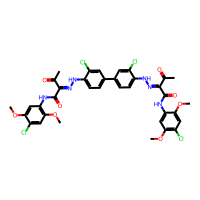

COc1cc(NC(=O)/C(=N/Nc2ccc(-c3ccc(N/N=C(\C(C)=O)C(=O)Nc4cc(OC)c(Cl)cc4OC)c(Cl)c3)cc2Cl)C(C)=O)c(OC)cc1Cl


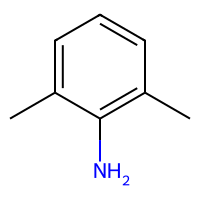

Cc1cccc(C)c1N


In [11]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def display_molecules_in_column(df, num_mols):
    for _, row in df.head(num_mols).iterrows():
        smi = row['SMILES']
        if smi is not None:
            mol = Chem.MolFromSmiles(smi)  # Create Mol object from SMILES
            if mol is not None:
                img = Draw.MolToImage(mol, size=(200, 200))
                display(img)
                print(smi)  # Prints the SMILES representation below the image

# Assuming 'df' is your DataFrame
# Display the first 10 molecules, each on a new row
display_molecules_in_column(moldf, 2)


Classes                          :  ['0' '1']
Number of cpds in each class     :  [380 414]
Total number of cpds             :  794


{'0': 0, '1': 1}

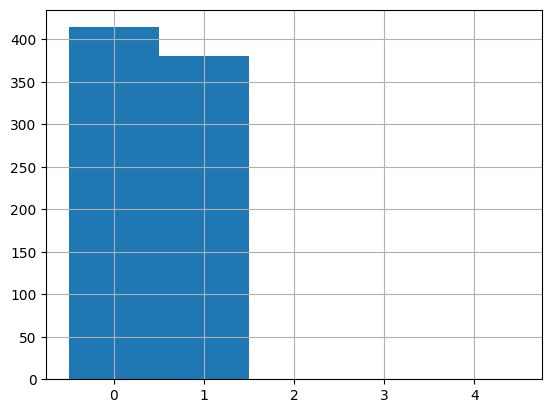

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(moldf['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( moldf['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S = moldf['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [13]:
x = x_data
y = y_data

In [14]:
x

,LabuteASA,TPSA,AMW,NumLipinskiHBA,NumLipinskiHBD,NumRotatableBonds,NumHBD,NumHBA,NumAmideBonds,NumHeteroAtoms,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
793,329.22569108280004,178.03999999999996,818.4979999999999,12,4,15,4,12,2,18,...,4.0,4.0,5.0,0.4814814814814814,17.0,3.0,178.03999999999996,6.832890014164742,12.134000000000002,0.1666666666666666
643,55.50117804530289,26.02,121.183,1,1,0,1,1,0,1,...,1.0,0.0,0.0,0.25,0.0,0.0,26.02,4.169925001442312,1.657,0.25
329,138.13317944083173,66.76,318.32800000000003,4,2,2,2,4,0,4,...,2.0,0.0,0.0,0.5,2.0,0.0,66.76,5.754887502163469,4.376000000000001,0.05
644,158.6712221498311,122.93,390.78300000000013,7,2,7,2,7,1,10,...,2.0,4.0,5.0,0.4615384615384615,8.0,1.0,122.93,5.807354922057604,6.3210000000000015,0.1176470588235294
327,64.23058843003683,46.53,152.14899999999997,3,1,2,1,3,0,3,...,1.0,0.0,2.0,0.4285714285714285,2.0,0.0,46.53,4.459431618637298,0.959,0.125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364,47.578717534978374,46.53,116.11599999999999,3,1,3,1,3,0,3,...,1.0,3.0,7.0,0.5,4.0,0.0,46.53,3.807354922057604,-0.1760000000000001,0.4
361,66.3630906449429,17.07,146.189,1,0,2,0,1,0,1,...,0.0,3.0,4.0,0.4285714285714285,2.0,0.0,17.07,4.459431618637298,2.171,0.1
360,105.52186862940262,52.60000000000001,246.26199999999994,4,0,6,0,4,0,4,...,0.0,3.0,6.0,0.4545454545454545,8.0,0.0,52.60000000000001,5.169925001442312,3.124,0.1428571428571428
390,182.0227184729849,58.92,494.46400000000006,4,2,17,2,4,0,14,...,2.0,3.0,20.0,0.4736842105263157,17.0,1.0,58.92,5.954196310386876,1.39,1.0


In [15]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [20]:
# Random Forest 
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# Param grid
paramgrid = {
    "n_estimators": [300],
    "max_features": [10,20],   # ≈ sqrt(56), 1/4, 1/3
    "max_depth": [7,15],
    "min_samples_leaf": [4, 6],
    "min_samples_split": [2,4]
}
# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring Cohen's Kappa
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV untuk RandomForest
model_rf_physicochemical = GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced'),
                     param_grid=paramgrid,
                     scoring=kappa_scorer,
                     cv=cv,
                     verbose=1,
                     n_jobs=-1)  

# Fit model
model_rf_physicochemical.fit(x, y)

# Best model
best_model_rf_physicochemical = model_rf_physicochemical.best_estimator_

print("Best parameters found: ", model_rf_physicochemical.best_params_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found:  {'max_depth': 15, 'max_features': 20, 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 300}


In [21]:
#Random Forest 
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_rf_physicochemical.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_rf_physicochemical.predict(X_test)
    y_proba = best_model_rf_physicochemical.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[54 29]
 [26 50]]
Confusion Matrix for Fold 2:
[[60 23]
 [16 60]]
Confusion Matrix for Fold 3:
[[55 28]
 [25 51]]
Confusion Matrix for Fold 4:
[[54 29]
 [35 41]]
Confusion Matrix for Fold 5:
[[56 26]
 [21 55]]
Overall CV Accuracy: 0.6750975240824776
Overall CV AUC: 0.7376741884096077
Overall CV Precision: 0.6532198420633172
Overall CV Recall (Sensitivity): 0.6763157894736842
Overall CV F1 Score: 0.6640447131750572
Overall CV Specificity: 0.67393476344402
Overall CV PPV (Positive Predictive Value): 0.6532198420633172
Overall CV NPV (Negative Predictive Value): 0.6971975969033923
Overall CV CCR (Correct Classification Rate): 0.6751252764588521


In [22]:
# SVM 
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.svm import SVC

# Param grid
paramgrid = {
    "C": [0.1, 1, 10, 100, 220, 440,],
    "kernel": ["rbf"],
    "gamma": [0.001, 0.01, 0.1, 1, "scale"]
}


# Cross-validator (5 splits)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring Cohen's Kappa
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV untuk SVM
model_svm_physicochemical = GridSearchCV(
    estimator=SVC(class_weight="balanced", probability=True),
    param_grid=paramgrid,   
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# Fit model
model_svm_physicochemical.fit(x, y)

# Best model
best_model_svm_physicochemical = model_svm_physicochemical.best_estimator_

print("Best parameters found: ", model_svm_physicochemical.best_params_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:  {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}


In [23]:
#SVM 
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_svm_physicochemical.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_svm_physicochemical.predict(X_test)
    y_proba = best_model_svm_physicochemical.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[62 21]
 [54 22]]
Confusion Matrix for Fold 2:
[[63 20]
 [42 34]]
Confusion Matrix for Fold 3:
[[63 20]
 [50 26]]
Confusion Matrix for Fold 4:
[[66 17]
 [50 26]]
Confusion Matrix for Fold 5:
[[64 18]
 [45 31]]
Overall CV Accuracy: 0.5755990765066475
Overall CV AUC: 0.6120145537219481
Overall CV Precision: 0.5887558303851819
Overall CV Recall (Sensitivity): 0.36578947368421055
Overall CV F1 Score: 0.45040582406985497
Overall CV Specificity: 0.7681457537466942
Overall CV PPV (Positive Predictive Value): 0.5887558303851819
Overall CV NPV (Negative Predictive Value): 0.5696252726117252
Overall CV CCR (Correct Classification Rate): 0.5669676137154523


In [24]:
#XGB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.impute import SimpleImputer
import pandas as pd

# Pastikan x numeric
x = x.apply(pd.to_numeric, errors="coerce")

# Imputer NaN
imputer = SimpleImputer(strategy="median")
x = pd.DataFrame(imputer.fit_transform(x), columns=x.columns)

y = pd.to_numeric(y, errors="coerce").astype(int)

# Parameter
paramgrid = {
    "max_depth": [2,5],
    "n_estimators": [50,100,150,200],
    "learning_rate": [0.05, 0.1,0.2]
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring Cohen's Kappa
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV untuk XGBClassifier
model_xgb_physicochemical = GridSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# Fit model
model_xgb_physicochemical.fit(x, y)

# Best model
best_model_xgb_physicochemical = model_xgb_physicochemical.best_estimator_

print("Best parameters found: ", model_xgb_physicochemical.best_params_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found:  {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 150}


In [25]:
#XGB Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_xgb_physicochemical.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_xgb_physicochemical.predict(X_test)
    y_proba = best_model_xgb_physicochemical.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[58 25]
 [30 46]]
Confusion Matrix for Fold 2:
[[60 23]
 [19 57]]
Confusion Matrix for Fold 3:
[[56 27]
 [30 46]]
Confusion Matrix for Fold 4:
[[61 22]
 [24 52]]
Confusion Matrix for Fold 5:
[[59 23]
 [24 52]]
Overall CV Accuracy: 0.6889340020698989
Overall CV AUC: 0.7542679060271896
Overall CV Precision: 0.6773120692562136
Overall CV Recall (Sensitivity): 0.6657894736842105
Overall CV F1 Score: 0.6712288581044906
Overall CV Specificity: 0.710167499265354
Overall CV PPV (Positive Predictive Value): 0.6773120692562136
Overall CV NPV (Negative Predictive Value): 0.6996475605984329
Overall CV CCR (Correct Classification Rate): 0.6879784864747823


In [26]:
# Neural Network 

import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

#Parameter
paramgrid = {
    "mlp__hidden_layer_sizes": [(256,128), (512,256,128), (1024,512,256,128)], 
    "mlp__activation": ["relu"],
    "mlp__solver": ["adam"],
    "mlp__alpha": [0.0001, 0.001],
    "mlp__learning_rate_init": [0.001]
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring Cohen's Kappa
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# Pipeline, scaling 
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=800,
        random_state=42,
        early_stopping=True
    ))
])

# GridSearchCV
model_nn_physicochemical = GridSearchCV(
    estimator=pipeline,
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=2,
    n_jobs=-1
)

# Fit model
model_nn_physicochemical.fit(x, y)
best_model_nn_physicochemical = model_nn_physicochemical.best_estimator_

print("Best parameters found:")
print(model_nn_physicochemical.best_params_)
print("Best CV Kappa:", model_nn_physicochemical.best_score_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters found:
{'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (1024, 512, 256, 128), 'mlp__learning_rate_init': 0.001, 'mlp__solver': 'adam'}
Best CV Kappa: 0.37419509686438046


In [27]:
#NN Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_nn_physicochemical.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_nn_physicochemical.predict(X_test)
    y_proba = best_model_nn_physicochemical.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[38 45]
 [20 56]]
Confusion Matrix for Fold 2:
[[56 27]
 [22 54]]
Confusion Matrix for Fold 3:
[[61 22]
 [30 46]]
Confusion Matrix for Fold 4:
[[62 21]
 [34 42]]
Confusion Matrix for Fold 5:
[[57 25]
 [21 55]]
Overall CV Accuracy: 0.6637847305150864
Overall CV AUC: 0.7327559274324512
Overall CV Precision: 0.6503518734226363
Overall CV Recall (Sensitivity): 0.6657894736842105
Overall CV F1 Score: 0.6538000183067159
Overall CV Specificity: 0.6619159565089626
Overall CV PPV (Positive Predictive Value): 0.6503518734226363
Overall CV NPV (Negative Predictive Value): 0.6840106732348111
Overall CV CCR (Correct Classification Rate): 0.6638527150965865


In [28]:
# LGBM 
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid: 2 × 2 × 2 = 8 kombinasi
paramgrid = {
     "max_depth": [3,6,9],
     "n_estimators": [300,500],
     "learning_rate": [0.05]
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring Cohen's Kappa
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV untuk LGBMClassifier
model_lgbm_physicochemical = GridSearchCV(
    estimator=LGBMClassifier(
        random_state=42,
        verbosity=-1
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# Fit model
model_lgbm_physicochemical.fit(x, y)

# Best model
best_model_lgbm_physicochemical = model_lgbm_physicochemical.best_estimator_

print("Best parameters found: ", model_lgbm_physicochemical.best_params_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters found:  {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300}


In [29]:
#LGBM Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_lgbm_physicochemical.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_lgbm_physicochemical.predict(X_test)
    y_proba = best_model_lgbm_physicochemical.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[53 30]
 [27 49]]
Confusion Matrix for Fold 2:
[[62 21]
 [15 61]]
Confusion Matrix for Fold 3:
[[57 26]
 [28 48]]
Confusion Matrix for Fold 4:
[[58 25]
 [27 49]]
Confusion Matrix for Fold 5:
[[57 25]
 [25 51]]
Overall CV Accuracy: 0.6863943953506887
Overall CV AUC: 0.7482287300678967
Overall CV Precision: 0.6692038091942221
Overall CV Recall (Sensitivity): 0.6789473684210526
Overall CV F1 Score: 0.6737591856325174
Overall CV Specificity: 0.693241257713782
Overall CV PPV (Positive Predictive Value): 0.6692038091942221
Overall CV NPV (Negative Predictive Value): 0.7031515865769812
Overall CV CCR (Correct Classification Rate): 0.6860943130674173


In [30]:
# Save model
import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Skin Sensitization\model\physical chemical properties model"

joblib.dump(
    best_model_rf_physicochemical,
    fr"{base_path}\Model_Skin_sens_RF_rdkit_cdk.pkl",
    compress=9
)

joblib.dump(
    best_model_svm_physicochemical,
    fr"{base_path}\Model_Skin_sens_SVM_rdkit_cdk.pkl",
    compress=9
)

joblib.dump(
    best_model_xgb_physicochemical,
    fr"{base_path}\Model_Skin_sens_XGB_rdkit_cdk.pkl",
    compress=9
)

joblib.dump(
    best_model_nn_physicochemical,
    fr"{base_path}\Model_Skin_sens_NN_rdkit_cdk.pkl",
    compress=9
)

joblib.dump(
    best_model_lgbm_physicochemical,
    fr"{base_path}\Model_Skin_sens_LGBM_rdkit_cdk.pkl",
    compress=9
)


['C:\\Users\\User\\Documents\\KULIAH TELKOM S1\\SKRIPSI\\UJI COBA QSAR - PRIBADI\\Skin Sensitization\\model\\physical chemical properties model\\Model_Skin_sens_LGBM_rdkit_cdk.pkl']